# 🧠 Is My Phone Listening?  
## Simulating Interest-Based Ad Targeting Using User Behavior Data

### Author: Anaya Vaz

---

### 📌 Objective
### To understand how platforms infer user interests using behavioral data and simulate how personalized ads are generated.

## Introduction

### Have you ever thought about something and suddenly started seeing ads for it?

### This project explores whether platforms actually "listen" to users, or if this effect is driven by data.

### We simulate how user behavior (clicks, views, interactions) is used to infer interests and deliver targeted ads.

## 🧩 Step 1: Simulating User Behavior Data

### We create a dataset representing user interactions across different categories such as Fitness, Beauty, Tech, etc.

In [7]:
import pandas as pd
import numpy as np

# Set a seed so the random results stay the same each time you run the code
np.random.seed(42)

# List of categories
categories = ["Fitness", "Beauty", "Tech", "Fashion", "Food"]

# Sample products under each category
products = {
    "Fitness": ["Yoga Mat", "Dumbbells", "Treadmill", "Protein Shaker"],
    "Beauty": ["Lipstick", "Face Wash", "Moisturizer", "Perfume"],
    "Tech": ["Laptop", "Smartphone", "Headphones", "Smartwatch"],
    "Fashion": ["T-Shirt", "Jeans", "Sneakers", "Jacket"],
    "Food": ["Pizza", "Burger", "Pasta", "Salad"]
}

# Create user IDs from U1 to U50
users = [f"U{i}" for i in range(1, 51)]

# Store all generated interactions here
data = []

# Generate 5 to 10 interactions for each user
for user in users:
    num_interactions = np.random.randint(5, 11)  # 11 is excluded, so this gives 5 to 10

    for _ in range(num_interactions):
        # Randomly pick a category
        category = np.random.choice(categories)

        # Randomly pick a product from that category
        product = np.random.choice(products[category])

        # Add the interaction record
        data.append({
            "user_id": user,
            "category": category,
            "product": product
        })

# Store everything in a dataframe called df
df = pd.DataFrame(data)

# Show the first 10 rows
print(df.head(10))


  user_id category      product
0      U1     Food        Pasta
1      U1     Tech   Smartwatch
2      U1     Food        Pizza
3      U1   Beauty  Moisturizer
4      U1     Tech   Headphones
5      U1     Food        Salad
6      U1     Tech   Smartphone
7      U1     Food       Burger
8      U2   Beauty      Perfume
9      U2  Fashion      T-Shirt


### 📊 Data Explanation

### Each row represents a user interaction:
#### - user_id → unique user
#### - product → item viewed/clicked
#### - category → type of interest

### This mimics how platforms track user behavior.

## 🧠 Step 2: Identifying User Interests

### We analyze user behavior to determine their dominant interests based on interaction frequency.

In [8]:
# Group by user_id and category, then count interactions
category_counts = (
    df.groupby(["user_id", "category"])
      .size()
      .reset_index(name="interaction_count")
)

# For each user, find the row with the highest interaction count
# If there is a tie, the first matching category will be selected
top_category_idx = category_counts.groupby("user_id")["interaction_count"].idxmax()

# Create the user_interest dataframe with user_id and top_category
user_interest = (
    category_counts.loc[top_category_idx, ["user_id", "category"]]
    .rename(columns={"category": "top_category"})
    .reset_index(drop=True)
)

# Show the first 10 rows
print(user_interest.head(10))


  user_id top_category
0      U1         Food
1     U10         Food
2     U11      Fashion
3     U12      Fitness
4     U13      Fitness
5     U14      Fitness
6     U15      Fashion
7     U16      Fitness
8     U17      Fashion
9     U18       Beauty


### 💡 Insight

#### Users tend to interact repeatedly within the same category, allowing platforms to confidently infer their interests.

## 🎯 Step 3: Simulating Ad Targeting

### Based on user interests, we recommend ads that align with their preferences.

In [9]:
# Dictionary that maps each category to relevant ads
category_ads = {
    "Fitness": ["Nike Shoes", "Gym Membership"],
    "Beauty": ["Skincare Kit", "Makeup Set"],
    "Tech": ["Smartphone", "Laptop"],
    "Fashion": ["Jackets", "Sneakers"],
    "Food": ["Protein Bars", "Snacks"]
}

# Function to recommend ads based on a user's top category
def recommend_ads(user_id):
    # Find the user's top category in user_interest
    user_row = user_interest[user_interest["user_id"] == user_id]

    # If the user is not found, return a helpful message
    if user_row.empty:
        return f"No data found for {user_id}"

    # Get the top category for that user
    top_category = user_row.iloc[0]["top_category"]

    # Return the ads for that category
    return category_ads.get(top_category, [])

# Test the function for a few users
print("U1:", recommend_ads("U1"))
print("U10:", recommend_ads("U10"))
print("U25:", recommend_ads("U25"))


U1: ['Protein Bars', 'Snacks']
U10: ['Protein Bars', 'Snacks']
U25: ['Skincare Kit', 'Makeup Set']


In [10]:
recommend_ads("U1")

['Protein Bars', 'Snacks']

## 🔄 Step 4: Improving Personalization

### Instead of using only one interest, we consider the top 2 categories to simulate more realistic ad targeting.

In [11]:
# Count how many times each user interacted with each category
category_counts = (
    df.groupby(["user_id", "category"])
      .size()
      .reset_index(name="interaction_count")
)

# For each user, keep the top 2 categories with highest interaction count
top_2_categories = (
    category_counts.sort_values(
        by=["user_id", "interaction_count"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .head(2)
    .reset_index(drop=True)
)

# Function to recommend ads from a user's top 2 categories
def recommend_ads(user_id):
    # Get the top 2 categories for the given user
    user_categories = top_2_categories[top_2_categories["user_id"] == user_id]

    # If user is not found, return a helpful message
    if user_categories.empty:
        return f"No data found for {user_id}"

    # Extract category names into a list
    categories = user_categories["category"].tolist()

    # Collect ads from both categories
    ads = []
    for category in categories:
        ads.extend(category_ads.get(category, []))

    return ads

# Show recommendations for a few users
print("U1:", recommend_ads("U1"))
print("U10:", recommend_ads("U10"))
print("U25:", recommend_ads("U25"))


U1: ['Protein Bars', 'Snacks', 'Smartphone', 'Laptop']
U10: ['Protein Bars', 'Snacks', 'Jackets', 'Sneakers']
U25: ['Skincare Kit', 'Makeup Set', 'Nike Shoes', 'Gym Membership']


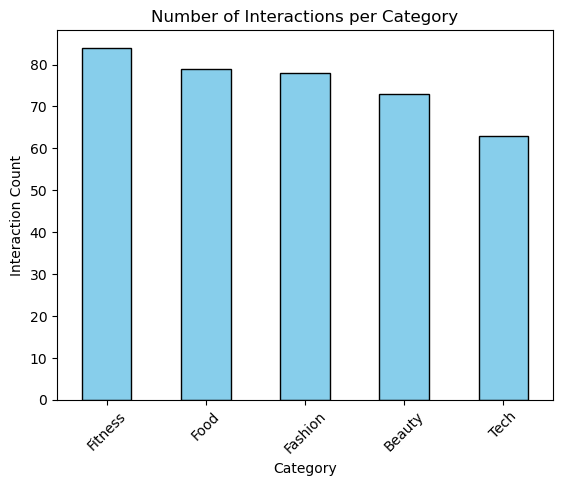

In [12]:
import matplotlib.pyplot as plt

# Count total interactions for each category
category_summary = df["category"].value_counts()

# Plot a simple bar chart
category_summary.plot(kind="bar", color="skyblue", edgecolor="black")

# Add title and labels
plt.title("Number of Interactions per Category")
plt.xlabel("Category")
plt.ylabel("Interaction Count")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the chart
plt.show()


## 📈 Observation

### Some categories dominate user behavior, which influences the type of ads shown.

## 💡 Key Takeaways

### - Platforms do not need to listen to conversations to predict user interests  
### - Behavioral data is sufficient to build accurate interest profiles  
### - Repeated engagement strengthens personalization  
### - This creates the illusion that devices are "listening"

## 🏁 Conclusion

### This project demonstrates that what feels like “mind reading” is actually the result of data-driven pattern recognition. By analyzing user behavior, platforms can deliver highly personalized ads, improving both user experience and business outcomes.